# Feature Detection & Matching (Corners, SIFT/ORB)
Detect and describe local features. Implement corner detection (Harris) and use feature detectors like SIFT
or ORB to find keypoints. Match features between image pairs to illustrate stitching or panorama concepts.
- Key tools: OpenCV (cv2.xfeatures2d for SIFT/ORB), Python.
- Expected outcome: Code that visualizes keypoints on images and draws lines between matching points,
forming the basis for image alignment. 

## What is Feature Matching?
Feature matching is a fundamental technique in computer vision that involves identifying and aligning corresponding features across multiple images. Features refer to distinctive elements in an image, such as edgews, corners, or blobs, that can be consistenly detected and described. By matching these features, computer vision systems can recognize objects, track movement, create panoramic images, and reconstruct 3D scene from 2D images.

### Key Aspects of Feature Matching
- Feature Detection
- Feature Description
- Feature Matching
- Feature Description

## Feature Matching Between Images Using ORB and RANSAC in OpenCV
- Loading Images: The images are loaded in grayscale.
- Feature Detection and Description: ORB (Oriented FAST adn Rotated BRIEF) is used to detect and compute features and descriptors.
- Matching Descritpors: The descriptors are matched using a brute force matcher.
- Drawing Matches: The top 10 matched are drawn and displayed.
- RANSAC Filtering:
    - The matching points are extracted.
    - The fundamental matrix is computed using RANSAC to filter out the outliers.
    - The inlier matches are drawn and displayed.

In [1]:
# load necessary libraries
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


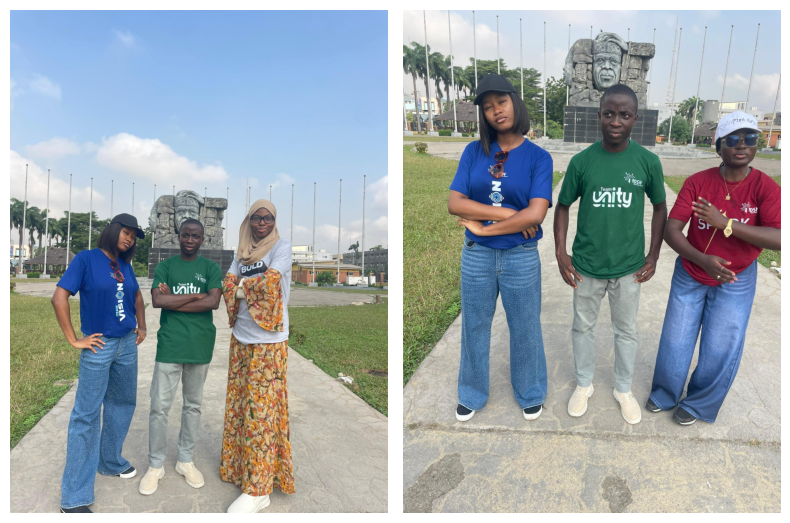

In [17]:
# Load and display the images
img1 = cv.imread('../data/pictures/pics/img_n_24.jpg')
img1_rgb = cv.imread('../data/pictures/pics/img_n_24.jpg', cv.IMREAD_COLOR_RGB)
img1_gray = cv.imread('../data/pictures/pics/img_n_24.jpg', cv.IMREAD_GRAYSCALE)

img2 = cv.imread('../data/pictures/pics/img_n_34.jpg')
img2_rgb = cv.imread('../data/pictures/pics/img_n_34.jpg', cv.IMREAD_COLOR_RGB)
img2_gray = cv.imread('../data/pictures/pics/img_n_34.jpg', cv.IMREAD_GRAYSCALE)

# Display the images
fig, ax = plt.subplots(1, 2, figsize=(8, 8))

ax[0].imshow(img1_rgb)
ax[0].axis('off')

ax[1].imshow(img2_rgb)
ax[1].axis('off')

plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
plt.show()

In [10]:
# Initialize ORB detector
orb = cv.ORB_create()

# Find the keypoints and descriptors with ORB
kp1, des1 = orb.detectAndCompute(img1_gray, None)
kp2, des2 = orb.detectAndCompute(img2_gray, None)

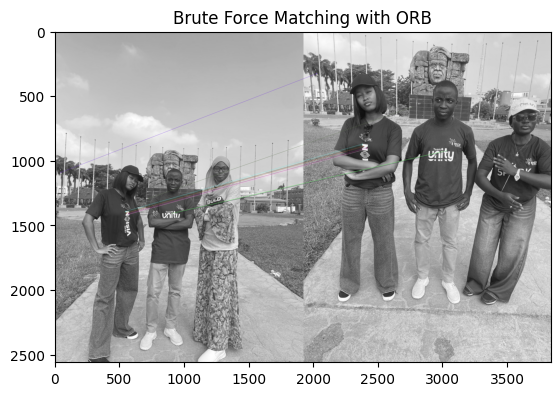

In [18]:
# Create a Brute Force Matcher object.
bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)

# Match descriptors.
matches = bf.match(des1, des2)

# Sort them in the order of their distance.
matches = sorted(matches, key=lambda x: x.distance)

# Draw the top 10 matches
img_matches = cv.drawMatches(img1_gray, kp1, img2_gray, kp2, matches[:10], None, 
                             flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display the matches
plt.imshow(img_matches)
plt.title('Brute Force Matching with ORB')
plt.show()

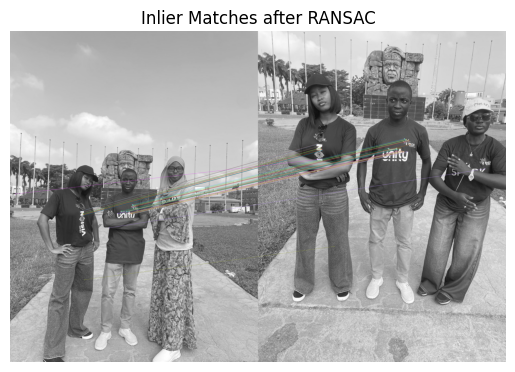

In [15]:
# Applying RANSAC to filter the matches
# Extract Location of good matches
pts1 = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

# Find the fundamental matrix
F, mask = cv.findFundamentalMat(pts1, pts2, cv.FM_RANSAC)

# Select inlier points
pts1 = pts1[mask.ravel() == 1]
pts2 = pts2[mask.ravel() == 1]

# Draw the inlier matches
img_inliers = cv.drawMatches(img1_gray, kp1, img2_gray, kp2, [m for i, m in enumerate(matches) if mask[i]], None,
                             flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display the inlier matches
plt.imshow(img_inliers)
plt.title("Inlier Matches after RANSAC")
plt.axis('off')
plt.show()

`Feature matching only works when images share overlapping content.`

## 3. Harris Corner Detection

Corner detection identifies points in an image where the intensity changes sharply in multiple directions. These points are often stable and repeatable, making them useful for feature extraction.

The Harris Corner Detector is a classical method that detects such points based on local image gradients.

(np.float64(-0.5), np.float64(1919.5), np.float64(2559.5), np.float64(-0.5))

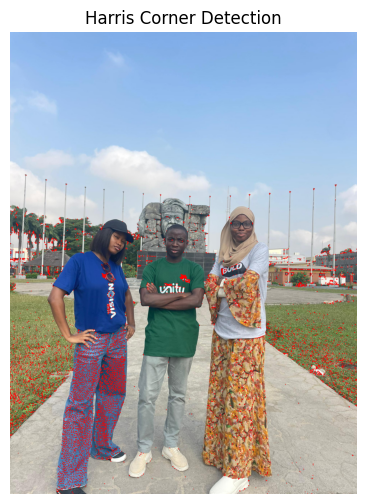

In [20]:
gray = cv.cvtColor(img1, cv.COLOR_BGR2GRAY)
gray = np.float32(gray)

# Apply Harris Corner Detector
corners = cv.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

# Enhance corner points
corners = cv.dilate(corners, None)

# Mark corners on the image
harris_img = img1.copy()
harris_img[corners > 0.01 * corners.max()] = [0, 0, 255]

plt.figure(figsize=(6, 6))
plt.imshow(cv.cvtColor(harris_img, cv.COLOR_BGR2RGB))
plt.title("Harris Corner Detection")
plt.axis('off')

**Key Takeaway:**
Harris detect *where* interesting points exist, but it does not describe them. To match features across images, we need feature descriptors.

## 4. Feature Detection and Description (SIFT)

SIFT (Scale-Invariant Feature Transform) detects keypoints and computes descriptors that are invariant to scale and rotation. Each keypoints is represented by a 128-dimensional vector describing local image gradients.

(np.float64(-0.5), np.float64(1919.5), np.float64(2559.5), np.float64(-0.5))

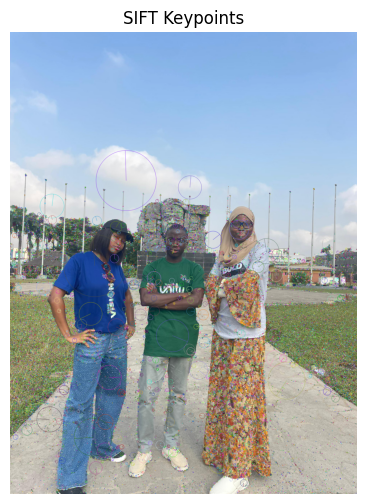

In [22]:
# Create SIFT detector
sift = cv.SIFT_create()

# Detect keypoints and compute descriptors
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# Draw keypoints
img1_sift = cv.drawKeypoints(
    img1, kp1, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(6, 6))
plt.imshow(cv.cvtColor(img1_sift, cv.COLOR_BGR2RGB))
plt.title("SIFT Keypoints")
plt.axis("off")

## 5. Feature Matching

Feature matching compares descriptors from different images to find corresponding points. We use a Brute-Force matcher with matcher with Euclidean distance and apply Lowe's ratio test to remove ambiguous matches.

(np.float64(-0.5), np.float64(3839.5), np.float64(2559.5), np.float64(-0.5))

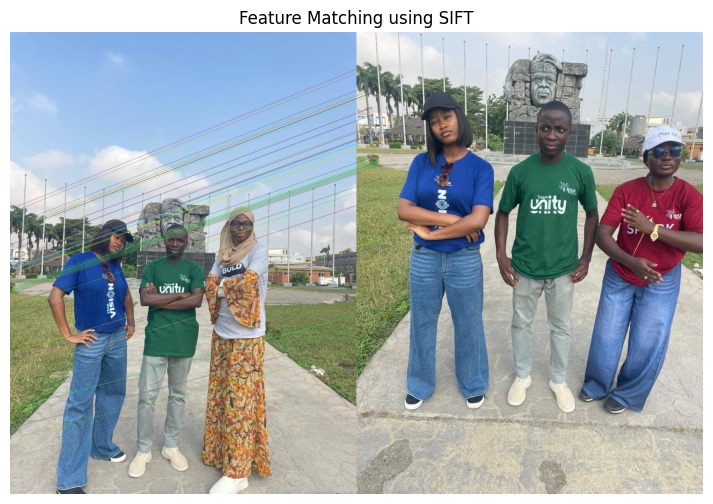

In [26]:
bf = cv.BFMatcher(cv.NORM_L2)
matches = bf.knnMatch(des1, des2, k=2)

# Apply Lowe's ratio test
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)


# Draw matches
matched_img = cv.drawMatches(
    img1, kp1, img2, kp2, good_matches[:50], None,
    flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(12, 6))
plt.imshow(cv.cvtColor(matched_img, cv.COLOR_BGR2RGB))
plt.title("Feature Matching using SIFT")
plt.axis("off")

## 6. Featrue Detection and Matching with ORB

ORB is a fast and efficient alternative to SIFT that use binary descriptors. It is suitable for real-time and resource-constrained applications.

(np.float64(-0.5), np.float64(3839.5), np.float64(2559.5), np.float64(-0.5))

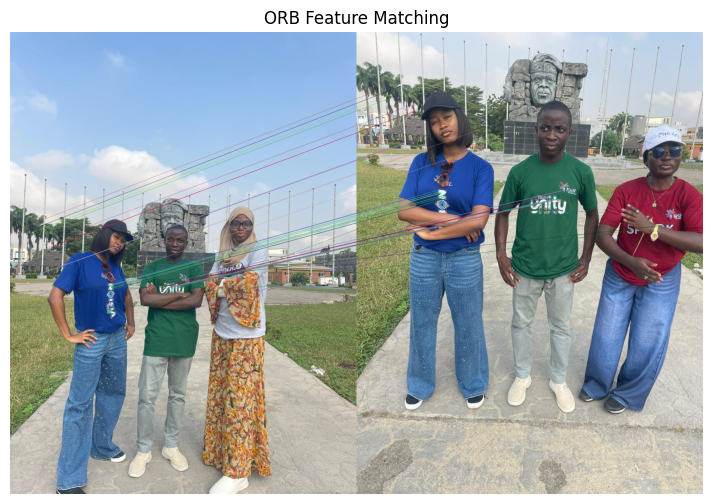

In [27]:
orb = cv.ORB_create(nfeatures=1000)

kp1_orb, des1_orb = orb.detectAndCompute(img1, None)
kp2_orb, des2_orb = orb.detectAndCompute(img2, None)

bf_orb = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
matches_orb = bf_orb.match(des1_orb, des2_orb)
matches_orb = sorted(matches_orb, key=lambda x: x.distance)

orb_matches_img = cv.drawMatches(
    img1, kp1_orb, img2, kp2_orb, matches_orb[:50], None
)

plt.figure(figsize=(12, 6))
plt.imshow(cv.cvtColor(orb_matches_img, cv.COLOR_BGR2RGB))
plt.title("ORB Feature Matching")
plt.axis("off")

## 7. Connection to Image Stitching

The matched feature points form correspondences between images. Theses correspondences are used to estimate a homography matrix, which allows one image to be warped and aligned with another.

This forms the foundation of image stitching and panorama creation, which will be explored in the next stage.

In [28]:
# Extract matched keypoint coordinates
src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

# Estimate homography matrix using RANSAC
H, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)

print("Homography Matrix:\n", H)

Homography Matrix:
 [[ 1.23684731e+00  1.53582361e-01 -1.01671614e+02]
 [ 2.99252237e-03  1.51334499e+00 -1.26460886e+03]
 [-6.29031311e-05  1.78449465e-04  1.00000000e+00]]


(np.float64(-0.5), np.float64(1919.5), np.float64(2559.5), np.float64(-0.5))

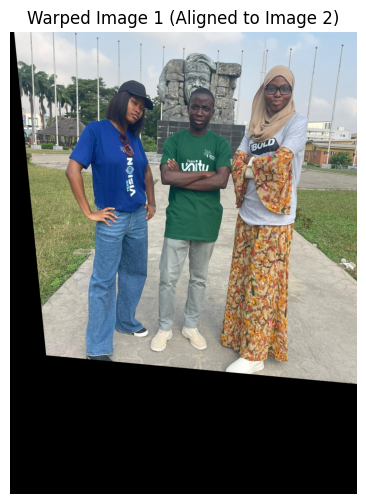

In [29]:
# Get dimensions of the second image
height, width, _ = img2.shape

# Warp image 1 to align with image 2
warped_img = cv.warpPerspective(img1, H, (width, height))

plt.figure(figsize=(6,6))
plt.imshow(cv.cvtColor(warped_img, cv.COLOR_BGR2RGB))
plt.title("Warped Image 1 (Aligned to Image 2)")
plt.axis("off")

(np.float64(-0.5), np.float64(1919.5), np.float64(2559.5), np.float64(-0.5))

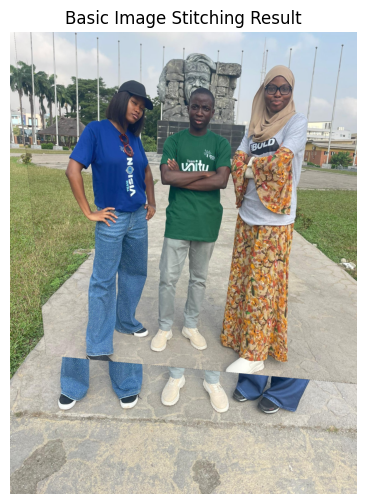

In [30]:
# Create a simple stitched output (overlay)
stitched = img2.copy()
mask = warped_img > 0
stitched[mask] = warped_img[mask]

plt.figure(figsize=(6,6))
plt.imshow(cv.cvtColor(stitched, cv.COLOR_BGR2RGB))
plt.title("Basic Image Stitching Result")
plt.axis("off")

## Final Key Takeaways

- Harris Corner Detection identifies interest points but does not describe them
- SIFT and ORB detect keypoints and compute descriptors
- Feature matching links corresponding points across images
- Lowe’s ratio test improves match reliability
- Feature matching is the foundation of image alignment and panorama stitching